# Step 6 — Model Evaluation and Analysis

This notebook loads the trained SER model and artifacts, evaluates it on a held-out split, and adds batch inference, diagnostics, visualizations, and export support.

## 1. Imports and configuration

In [1]:
# ============================================================
# Notebook 6 - Emotion Prediction & Inference
# ============================================================

import pickle
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import torch

from transformers import (
    AutoFeatureExtractor,
    Wav2Vec2ForSequenceClassification
)

# ------------------------------------------------------------
# CPU Configuration (Mac 4-Core)
# ------------------------------------------------------------

DEVICE = torch.device("cpu")

torch.set_num_threads(4)

# ------------------------------------------------------------

BASE_DIR = Path.cwd()
PROJECT_ROOT = BASE_DIR.parent.parent

MODEL_DIR = PROJECT_ROOT / "models" / "wav2vec2_ser"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
INFERENCE_DIR = OUTPUT_DIR / "inference"

INFERENCE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TARGET_SR = 16000

print("=" * 70)
print("Notebook 6 - Emotion Prediction")
print("=" * 70)

print("Device :", DEVICE)
print("CPU Threads :", torch.get_num_threads())
print("Model :", MODEL_DIR)

print("=" * 70)

/opt/homebrew/Caskroom/miniforge/base/envs/malaria_gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Notebook 6 - Emotion Prediction
Device : cpu
CPU Threads : 4
Model : /Users/devanshbansal/Desktop/ser/models/wav2vec2_ser


## 2. Load Fine-tunned model

In [2]:
# ============================================================
# Load Fine-Tuned Model
# ============================================================

feature_extractor = AutoFeatureExtractor.from_pretrained(
    MODEL_DIR
)

model = Wav2Vec2ForSequenceClassification.from_pretrained(
    MODEL_DIR
)

model.to(DEVICE)
model.eval()

LABEL_ENCODER_PATH = (
    PROJECT_ROOT 
    / "outputs"
    / "prepared_training"
    / "label_encoder.pkl"
)

with open(LABEL_ENCODER_PATH, "rb") as f:
    label_encoder = pickle.load(f)

print("=" * 70)
print("Model Loaded Successfully")
print("=" * 70)

print("Classes")

for i, c in enumerate(label_encoder.classes_):
    print(i, c)

Loading weights: 100%|██████████| 215/215 [00:00<00:00, 9562.33it/s]

Model Loaded Successfully
Classes
0 angry
1 calm
2 disgust
3 fearful
4 happy
5 neutral
6 sad
7 surprised


## 3. prediction function

In [3]:
# ============================================================
# Emotion Prediction Function
# ============================================================

def predict_emotion(audio_path):

    waveform, sr = librosa.load(
        audio_path,
        sr=16000
    )

    inputs = feature_extractor(
        waveform,
        sampling_rate=16000,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(DEVICE)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = model(**inputs)

        probs = torch.softmax(
            outputs.logits,
            dim=-1
        )

    pred = torch.argmax(probs).item()

    return (
        label_encoder.inverse_transform([pred])[0],
        probs.squeeze().cpu().numpy(),
        waveform
    )

## 4. Single Audio Prediction

In [4]:
# ============================================================
# Emotion Prediction Function
# ============================================================

def predict_emotion(audio_path):

    waveform, sr = librosa.load(
        audio_path,
        sr=16000
    )

    inputs = feature_extractor(
        waveform,
        sampling_rate=16000,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(DEVICE)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        outputs = model(**inputs)

        probs = torch.softmax(
            outputs.logits,
            dim=-1
        )

    pred = torch.argmax(probs).item()

    return (
        label_encoder.inverse_transform([pred])[0],
        probs.squeeze().cpu().numpy(),
        waveform
    )

In [5]:
# ============================================================
# Run Prediction
# ============================================================

audio_path = "/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_01/03-01-01-01-01-01-01.wav"


emotion, probs, waveform = predict_emotion(audio_path)


print("=" * 70)
print("Prediction Completed")
print("=" * 70)

print("Audio File       :", audio_path)
print("Predicted Emotion:", emotion)
print("Audio Samples    :", len(waveform))
print("Sampling Rate    :", TARGET_SR)

print("=" * 70)

Prediction Completed
Audio File       : /Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_01/03-01-01-01-01-01-01.wav
Predicted Emotion: calm
Audio Samples    : 52853
Sampling Rate    : 16000


## 5. Plot waveform

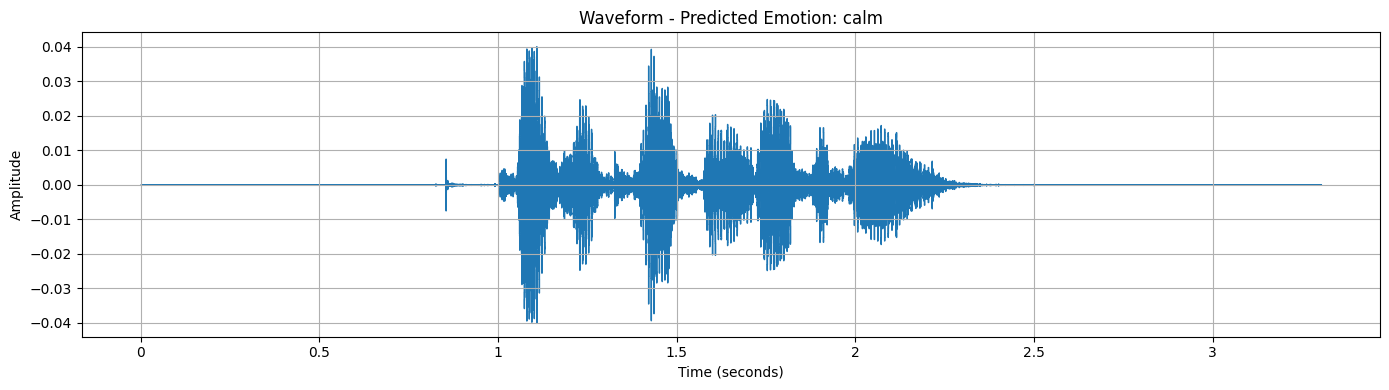

In [6]:
# ============================================================
# Plot Waveform
# ============================================================

plt.figure(figsize=(14,4))

librosa.display.waveshow(
    waveform,
    sr=TARGET_SR
)

plt.title(f"Waveform - Predicted Emotion: {emotion}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.grid(True)
plt.tight_layout()

plt.show()

In [7]:
print("predict_emotion" in globals())

True


## 6. Prediction Probabilities


In [8]:
from pathlib import Path


audio_path = input("Paste full wav file path: ") 
audio_path = "/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_01/03-01-01-01-01-01-01.wav"

audio_path = Path(audio_path)

if not audio_path.exists():
    raise FileNotFoundError(f"Audio file not found: {audio_path}")

emotion, probs, waveform = predict_emotion(str(audio_path))

print("=" * 70)
print("Prediction Completed")
print("=" * 70)

print("File:", audio_path.name)
print("Emotion:", emotion)
print("Samples:", len(waveform))
print("=" * 70)

Prediction Completed
File: 03-01-01-01-01-01-01.wav
Emotion: calm
Samples: 52853


In [9]:
import pandas as pd
prob_df = pd.DataFrame({
    "Emotion": label_encoder.classes_,
    "Probability": probs
})

prob_df = prob_df.sort_values(
    "Probability",
    ascending=False
).reset_index(drop=True)

display(prob_df)

,Emotion,Probability
0,calm,0.289514
1,sad,0.224770
2,neutral,0.157218
3,disgust,0.086698
4,happy,0.068103
5,fearful,0.060407
6,surprised,0.058398
7,angry,0.054891


## 7. Top-K  Predictions

In [10]:
# ============================================================
# Top Predictions
# ============================================================

TOP_K = 3

top = prob_df.head(TOP_K)

print("="*70)

for _, row in top.iterrows():

    print(
        f"{row.Emotion:12s}"
        f"{row.Probability*100:.2f}%"
    )

print("="*70)

calm        28.95%
sad         22.48%
neutral     15.72%


## 8. Predict Multiple files

In [11]:
from pathlib import Path

print(Path("/Users/devanshbansal/Desktop/ser/dataset").exists())
print(Path("/Users/devanshbansal/Desktop/ser").exists())

True
True


In [12]:
# ============================================================
# Batch Prediction
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

AUDIO_DIR = Path("/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24")

if not AUDIO_DIR.exists():
    raise FileNotFoundError(f"{AUDIO_DIR} does not exist.")

# Get every wav file in the folder and its subfolders
audio_files = sorted(AUDIO_DIR.rglob("*.wav"))

print("=" * 70)
print(f"Found {len(audio_files)} wav files.")
print("=" * 70)

results = []

for audio in audio_files:

    emotion, probs, waveform = predict_emotion(str(audio))

    results.append({
        "file": audio.name,
        "prediction": emotion,
        "confidence": float(np.max(probs))
    })

results_df = pd.DataFrame(results)

display(results_df)

Found 1440 wav files.


,file,prediction,confidence
0,03-01-01-01-01-01-01.wav,calm,0.289514
1,03-01-01-01-01-02-01.wav,calm,0.291654
2,03-01-01-01-02-01-01.wav,calm,0.316141
3,03-01-01-01-02-02-01.wav,calm,0.296589
4,03-01-02-01-01-01-01.wav,calm,0.312543
...,...,...,...
1435,03-01-08-01-02-02-24.wav,fearful,0.188292
1436,03-01-08-02-01-01-24.wav,fearful,0.198407
1437,03-01-08-02-01-02-24.wav,fearful,0.196249
1438,03-01-08-02-02-01-24.wav,fearful,0.205816


## 9. Save Prediction

In [25]:
print(AUDIO_DIR)
print(AUDIO_DIR.exists())

/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24
True


In [26]:
from pathlib import Path

AUDIO_DIR = Path(
    "/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24"
)
for item in AUDIO_DIR.iterdir():
    print(item)

/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_16
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_11
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_18
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_20
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_21
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_19
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_10
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_17
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/.DS_Store
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_04
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_03
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_02
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_05
/Users/deva

In [27]:
# ============================================================
# Save Prediction Results
# ============================================================

OUTPUT_FILE = (
    INFERENCE_DIR /
    "prediction_results.csv"
)

results_df.to_csv(
    OUTPUT_FILE,
    index=False
)

print("="*70)
print("Saved")

print(OUTPUT_FILE)
print("="*70)

Saved
/Users/devanshbansal/Desktop/ser/outputs/inference/prediction_results.csv


In [16]:
from pathlib import Path

AUDIO_DIR = Path("/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24")

print("Folders:")

for actor in AUDIO_DIR.iterdir():
    if actor.is_dir():
        print(actor.name)

        files = list(actor.iterdir())[:5]

        for f in files:
            print("   ", f.name)

        break

Folders:
Actor_16
    03-01-05-01-02-01-16.wav
    03-01-06-01-02-02-16.wav
    03-01-06-02-01-02-16.wav
    03-01-05-02-01-01-16.wav
    03-01-07-01-01-01-16.wav


In [28]:
from pathlib import Path

AUDIO_DIR = Path("/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24")

wavs = list(AUDIO_DIR.rglob("*"))

print("Total files/folders:", len(wavs))

for x in wavs[:20]:
    print(x)

Total files/folders: 1465
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_16
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_11
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_18
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_20
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_21
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_19
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_10
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_17
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/.DS_Store
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_04
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_03
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_02
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_

In [29]:
print(type(audio_files))
print(len(audio_files))
print(audio_files[0])

<class 'list'>
1440
/Users/devanshbansal/Desktop/ser/dataset/Audio_Speech_Actors_01-24/Actor_01/03-01-01-01-01-01-01.wav


In [30]:
results_df.head()

,file,prediction,confidence
0,03-01-01-01-01-01-01.wav,calm,0.289514
1,03-01-01-01-01-02-01.wav,calm,0.291654
2,03-01-01-01-02-01-01.wav,calm,0.316141
3,03-01-01-01-02-02-01.wav,calm,0.296589
4,03-01-02-01-01-01-01.wav,calm,0.312543


In [31]:
results_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   file        1440 non-null   object 
 1   prediction  1440 non-null   object 
 2   confidence  1440 non-null   float64
dtypes: float64(1), object(2)
memory usage: 33.9+ KB


In [32]:
print(results)


[{'file': '03-01-01-01-01-01-01.wav', 'prediction': 'calm', 'confidence': 0.2895143926143646}, {'file': '03-01-01-01-01-02-01.wav', 'prediction': 'calm', 'confidence': 0.29165419936180115}, {'file': '03-01-01-01-02-01-01.wav', 'prediction': 'calm', 'confidence': 0.3161405622959137}, {'file': '03-01-01-01-02-02-01.wav', 'prediction': 'calm', 'confidence': 0.29658886790275574}, {'file': '03-01-02-01-01-01-01.wav', 'prediction': 'calm', 'confidence': 0.3125433325767517}, {'file': '03-01-02-01-01-02-01.wav', 'prediction': 'calm', 'confidence': 0.31532591581344604}, {'file': '03-01-02-01-02-01-01.wav', 'prediction': 'calm', 'confidence': 0.31553301215171814}, {'file': '03-01-02-01-02-02-01.wav', 'prediction': 'calm', 'confidence': 0.3237101435661316}, {'file': '03-01-02-02-01-01-01.wav', 'prediction': 'calm', 'confidence': 0.3215346336364746}, {'file': '03-01-02-02-01-02-01.wav', 'prediction': 'calm', 'confidence': 0.32225868105888367}, {'file': '03-01-02-02-02-01-01.wav', 'prediction': 'ca

## 10. Prediction distriution

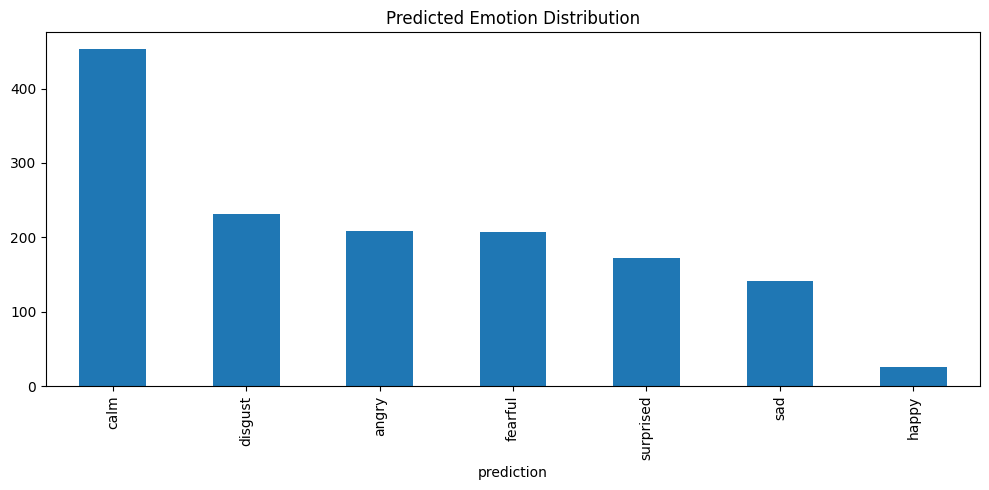

In [33]:
# ============================================================
# Prediction Distribution
# ============================================================

plt.figure(figsize=(10,5))

results_df["prediction"].value_counts().plot(
    kind="bar"
)

plt.title("Predicted Emotion Distribution")

plt.tight_layout()

plt.show()

## 11. Inference Summary

In [34]:
# ============================================================
# Inference Summary
# ============================================================

print("="*70)

print("Total Files")

print(len(results_df))

print()

print(
    results_df["prediction"]
    .value_counts()
)

print("="*70)

Total Files
1440

prediction
calm         453
disgust      232
angry        209
fearful      207
surprised    172
sad          141
happy         26
Name: count, dtype: int64


## 12. Notebook Completion


In [35]:
# ============================================================
# Notebook Completed
# ============================================================

print("="*70)
print("NOTEBOOK 6 COMPLETED SUCCESSFULLY")
print("="*70)

print("Completed")

print("✓ Model Loaded")
print("✓ Single Audio Prediction")
print("✓ Batch Prediction")
print("✓ Waveform Visualization")
print("✓ Confidence Scores")
print("✓ Results Saved")

print()
print("Next Notebook")
print("Notebook 7 - Model Evaluation & Analysis")

print("="*70)

NOTEBOOK 6 COMPLETED SUCCESSFULLY
Completed
✓ Model Loaded
✓ Single Audio Prediction
✓ Batch Prediction
✓ Waveform Visualization
✓ Confidence Scores
✓ Results Saved

Next Notebook
Notebook 7 - Model Evaluation & Analysis
